In [6]:
%matplotlib inline

In [25]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix,
    classification_report,
    accuracy_score,
    roc_curve,
    auc,
    RocCurveDisplay,
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
import mglearn
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "DejaVu Sans"
import seaborn as sns
import time

In [26]:
parquet_file_name = 'Bourbaki NLP Avanzado.parquet'
df = pd.read_parquet(parquet_file_name)
print(f"Successfully loaded '{parquet_file_name}' into a pandas DataFrame.")
print("First 5 rows of the DataFrame:")
print(df.head())

Successfully loaded 'Bourbaki NLP Avanzado.parquet' into a pandas DataFrame.
First 5 rows of the DataFrame:
                                            sentence  label  idx
0  Our friends won't buy this analysis, let alone...      1    0
1  One more pseudo generalization and I'm giving up.      1    1
2   One more pseudo generalization or I'm giving up.      1    2
3     The more we study verbs, the crazier they get.      1    3
4          Day by day the facts are getting murkier.      1    4


In [27]:
# Define features (X) and target (y)
X_text = df["sentence"].astype(str)
y = df["label"].astype(int).to_numpy().ravel()

In [28]:
# Split the data into training and testing sets
# test_size: The proportion of the dataset to include in the test split.
# random_state: Controls the shuffling applied to the data before applying the split.
X_train, X_test, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (6840,)
Shape of X_test: (1711,)
Shape of y_train: (6840,)
Shape of y_test: (1711,)


In [29]:
pipe = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000, stop_words='english')),
    ("clf", LogisticRegression(max_iter=5000, random_state=42, solver="liblinear")),
])

In [30]:
param_grid = {
    # Vectorizer
    "tfidf__max_features": [5000, 10000],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [1, 2, 5],

    # Logistic Regression
    "clf__C": [0.1, 1, 10],
    "clf__class_weight": [None, "balanced"]
}

In [31]:
clf = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=1
)

In [32]:
# Train the model using the training data
t0 = time.perf_counter()
clf.fit(X_train, y_train)
t1 = time.perf_counter()

print(f"grid_training_time_s: {(t1-t0):.3f} s")
print("Best params:", clf.best_params_)
print("Best CV score (F1):", clf.best_score_)

best_model = clf.best_estimator_

Fitting 5 folds for each of 72 candidates, totalling 360 fits
grid_training_time_s: 32.650 s
Best params: {'clf__C': 1, 'clf__class_weight': None, 'tfidf__max_features': 10000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}
Best CV score (F1): 0.7061403508771931


In [33]:
# Make predictions on the test set
t0 = time.perf_counter()
y_pred = best_model.predict(X_test) # predicts whether a review is fake or real
t1 = time.perf_counter()
print("\nClassification Report (TEST):")
print(classification_report(y_test, y_pred, digits=4))
print(f"inference_1_sentence_ms: {(t1-t0)*1000:.3f} ms")

# Evaluate the model's accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Logistic Regression Model Accuracy: {accuracy:.4f}")

print("Training set score: {:.3f}".format(clf.score(X_test, y_test)))
print(classification_report(y_test, y_pred))


Classification Report (TEST):
              precision    recall  f1-score   support

           0     0.4096    0.0672    0.1154       506
           1     0.7101    0.9593    0.8161      1205

    accuracy                         0.6955      1711
   macro avg     0.5599    0.5133    0.4658      1711
weighted avg     0.6212    0.6955    0.6089      1711

inference_1_sentence_ms: 20.581 ms
Logistic Regression Model Accuracy: 0.6955
Training set score: 0.695
              precision    recall  f1-score   support

           0       0.41      0.07      0.12       506
           1       0.71      0.96      0.82      1205

    accuracy                           0.70      1711
   macro avg       0.56      0.51      0.47      1711
weighted avg       0.62      0.70      0.61      1711



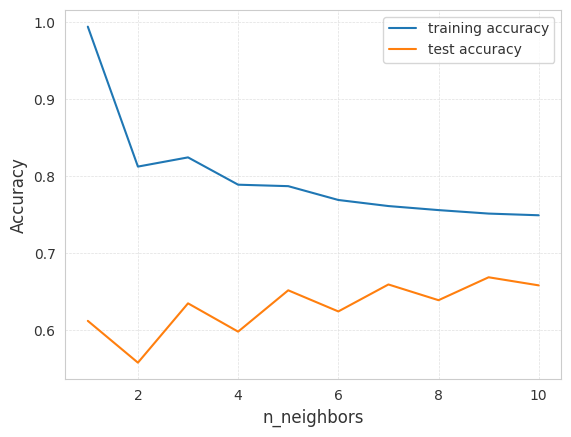

In [34]:
training_accuracy = []
test_accuracy = []
neighbors_settings = range(1, 11)

for n_neighbors in neighbors_settings:
  clf = Pipeline([
      ("tfidf", TfidfVectorizer(ngram_range=(1,2), min_df=2)),
      ("knn", KNeighborsClassifier(n_neighbors=n_neighbors))
  ])
  clf.fit(X_train, y_train)
  training_accuracy.append(clf.score(X_train, y_train))
  test_accuracy.append(clf.score(X_test, y_test))

plt.plot(
    neighbors_settings,
    training_accuracy,
    label="training accuracy",
)
plt.plot(
    neighbors_settings,
    test_accuracy,
    label="test accuracy",
)
plt.ylabel("Accuracy")
plt.xlabel("n_neighbors")
plt.legend()

## Confusion Matrix

AUC Score: 0.5133

Confusion Matrix:
[[  34  472]
 [  49 1156]]


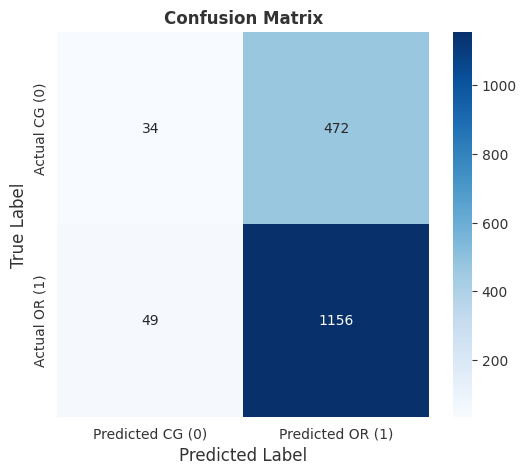


Classification Report:
              precision    recall  f1-score   support

           0       0.41      0.07      0.12       506
           1       0.71      0.96      0.82      1205

    accuracy                           0.70      1711
   macro avg       0.56      0.51      0.47      1711
weighted avg       0.62      0.70      0.61      1711



In [35]:
# Calculate AUC
auc_score = roc_auc_score(y_test, y_pred)
print(f"AUC Score: {auc_score:.4f}")

# Calculate Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

# Plotting the Confusion Matrix for better visualization
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted CG (0)', 'Predicted OR (1)'],
            yticklabels=['Actual CG (0)', 'Actual OR (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Display Classification Report
class_report = classification_report(y_test, y_pred)
print("\nClassification Report:")
print(class_report)

## GLOBAL Explainability

In [36]:
tfidfG = best_model.named_steps["tfidf"]
lr = best_model.named_steps["clf"]

feature_namesG = tfidfG.get_feature_names_out()
coefs = lr.coef_.ravel()  # binario => shape (n_features,)

top_n = 20
top_pos_idx = np.argsort(coefs)[-top_n:][::-1]  # more positive values => class 1
top_neg_idx = np.argsort(coefs)[:top_n]         # more negative values => class 0

top_pos = pd.DataFrame({
    "Feature": feature_namesG[top_pos_idx],
    "Coef": coefs[top_pos_idx]
})

top_neg = pd.DataFrame({
    "Feature": feature_namesG[top_neg_idx],
    "Coef": coefs[top_neg_idx]
})

top_pos_sorted = top_pos.sort_values("Coef", ascending=True)
top_neg_sorted = top_neg.sort_values("Coef", ascending=True)

#print("Top 20 toward class 1 (positive coefficients):")
#display(top_pos)

#print("\nTop 20 toward class 0 (negative coefficients):")
#display(top_neg)

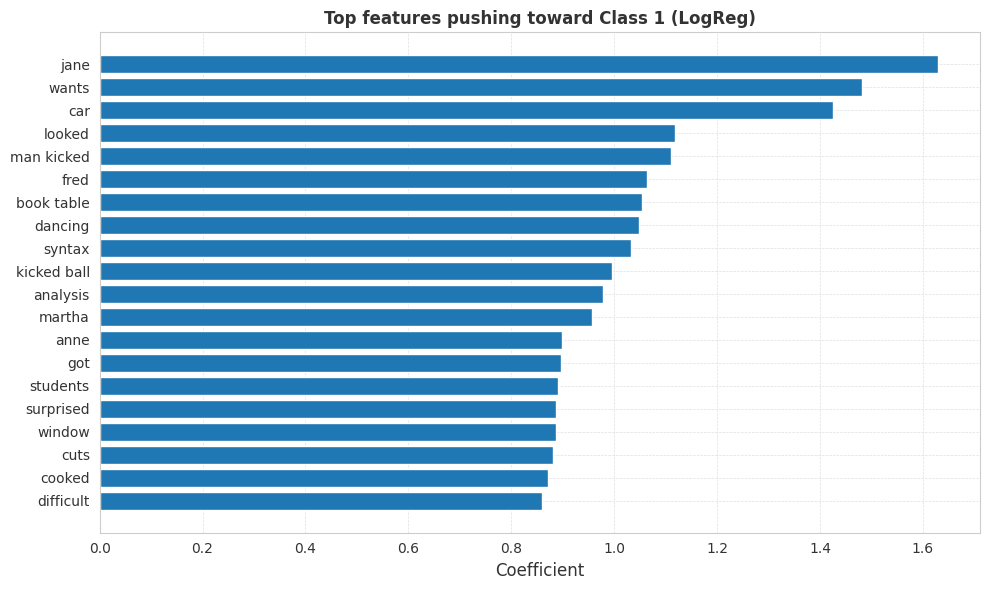

In [37]:
plt.figure(figsize=(10, 6))
plt.barh(top_pos_sorted["Feature"], top_pos_sorted["Coef"])
plt.title("Top features pushing toward Class 1 (LogReg)")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()

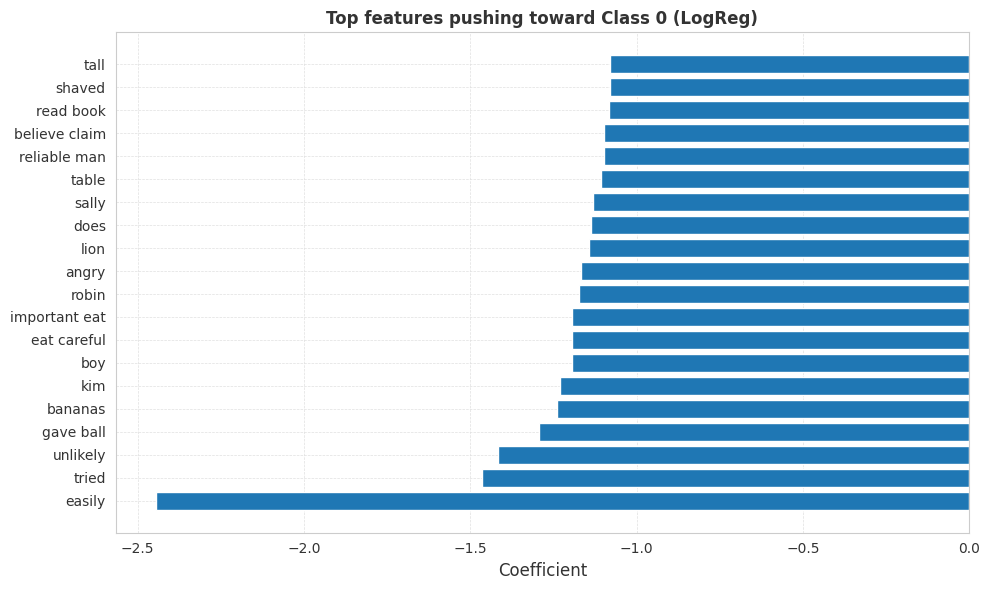

In [38]:
plt.figure(figsize=(10, 6))
plt.barh(top_neg_sorted["Feature"], top_neg_sorted["Coef"])
plt.title("Top features pushing toward Class 0 (LogReg)")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()

## LOCAL Explainability

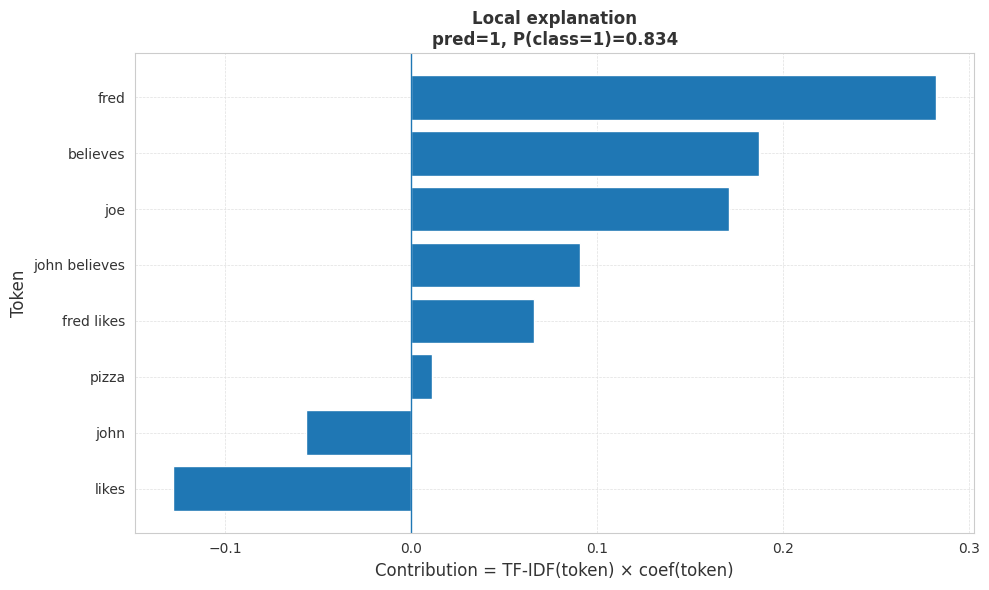

John believes that Fred likes steak that Joe likes pizza.


In [39]:
def plot_local_explanation_lr(best_model, text, top_k=10, title_prefix="Local explanation"):
    tfidf = best_model.named_steps["tfidf"]
    lr = best_model.named_steps["clf"]

    feature_names = tfidf.get_feature_names_out()
    coefs = lr.coef_.ravel()

    # Vector TF-IDF de 1 texto
    x = tfidf.transform([text])  # sparse (1, n_features)

    # indices of present features
    idx = x.nonzero()[1]
    tfidf_vals = x.data
    contrib = tfidf_vals * coefs[idx]

    df = pd.DataFrame({
        "token": feature_names[idx],
        "tfidf": tfidf_vals,
        "coef": coefs[idx],
        "contrib": contrib
    })

    # Top contributors pushing to 1 and to 0
    top_pos = df.sort_values("contrib", ascending=False).head(top_k)
    top_neg = df.sort_values("contrib", ascending=True).head(top_k)

    plot_df = pd.concat([top_neg, top_pos], axis=0).sort_values("contrib", ascending=True)

    # Prediction and probability (if available)
    pred = best_model.predict([text])[0]
    proba = best_model.predict_proba([text])[0, 1] if hasattr(lr, "predict_proba") else None

    plt.figure(figsize=(10, 6))
    plt.barh(plot_df["token"], plot_df["contrib"])
    plt.axvline(0, linewidth=1)
    subtitle = f"pred={pred}" + (f", P(class=1)={proba:.3f}" if proba is not None else "")
    plt.title(f"{title_prefix}\n{subtitle}")
    plt.xlabel("Contribution = TF-IDF(token) × coef(token)")
    plt.ylabel("Token")
    plt.tight_layout()
    plt.show()

    return plot_df, pred, proba

# ---- Ejemplo de uso ----
# If your test set is in X_test (Series/list of strings):
text_example = X_test.iloc[0] if hasattr(X_test, "iloc") else X_test[0]

plot_df, pred, proba = plot_local_explanation_lr(best_model, text_example, top_k=12)
print(text_example)

## Decision Tree

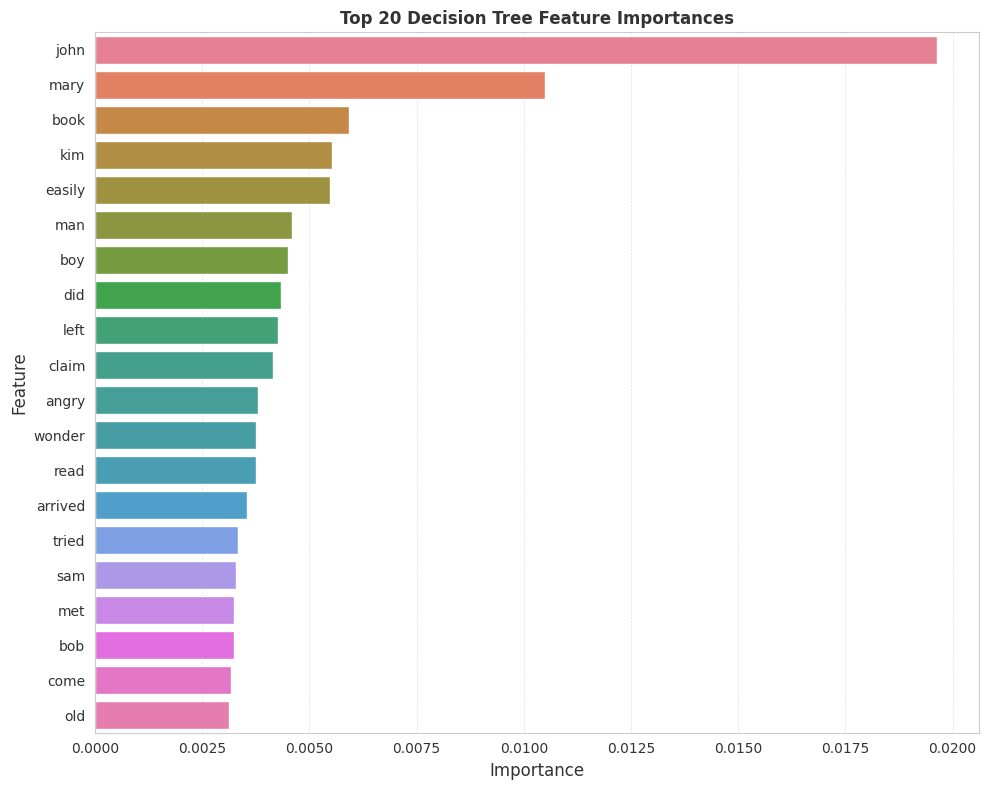

In [40]:
# Temporarily adjust font settings to suppress font warnings
# 'DejaVu Sans' is usually available in Colab environments
original_font_sans_serif = plt.rcParams['font.sans-serif']
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'sans-serif']

pipe_dt = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000, stop_words='english')),
    ("classifier", DecisionTreeClassifier(random_state=0))
])

pipe_dt.fit(df["sentence"], df["label"].to_numpy().ravel())
feature_names = pipe_dt.named_steps["tfidf"].get_feature_names_out()

# 1. Access feature importances from the best Decision Tree model
dt_feature_importances = pipe_dt.named_steps['classifier'].feature_importances_

# 2. Create a Pandas DataFrame
dt_feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': dt_feature_importances
})

# 3. Sort the DataFrame in descending order
dt_feature_importance_df = dt_feature_importance_df.sort_values(by='Importance', ascending=False)

# 4. Select the top 20 most important features
top_20_dt_features = dt_feature_importance_df.head(20)

# 5-9. Create a horizontal bar plot
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=top_20_dt_features, hue='Feature', legend=False)
plt.title('Top 20 Decision Tree Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()

# 10. Display the plot
plt.show()

# Revert font settings to original if needed for subsequent plots
plt.rcParams['font.sans-serif'] = original_font_sans_serif

## ROC Plot

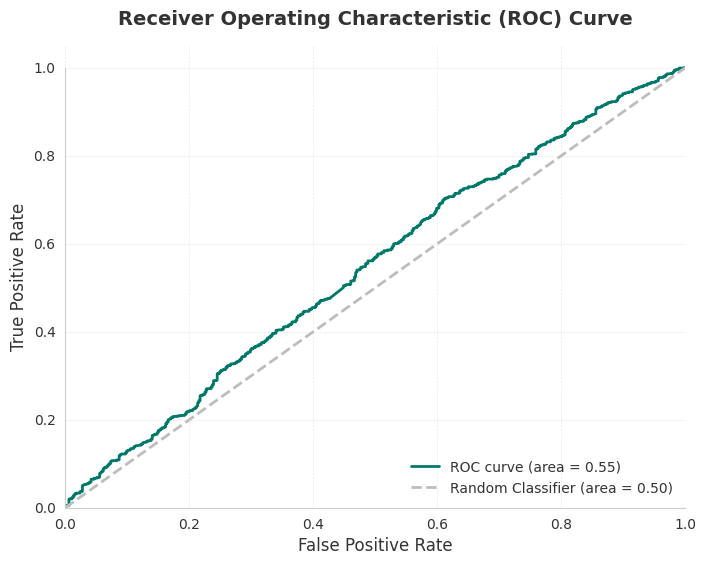

In [42]:
# Get prediction probabilities for the positive class (class 1)
y_proba = best_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

# --- Financial Times style emulation ---
# Set a clean style
sns.set_style("whitegrid", {"axes.edgecolor": "#cccccc", "grid.color": "#e0e0e0"})
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Arial', 'Helvetica', 'Lato'],
    'axes.titleweight': 'bold',
    'axes.labelweight': 'normal',
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 14,
    'grid.linestyle': '--',
    'grid.linewidth': 0.5,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'text.color': '#333333',
    'axes.labelcolor': '#333333',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'legend.fontsize': 10
})

plt.figure(figsize=(8, 6))

# Plot ROC curve
plt.plot(fpr, tpr, color='#00796B', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')

# Plot random classifier line
plt.plot([0, 1], [0, 1], color='#BDBDBD', lw=2, linestyle='--', label='Random Classifier (area = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, pad=15)
plt.legend(loc='lower right', frameon=False)
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

# Remove top and right spines for cleaner look
sns.despine(trim=True)

plt.show()

## Computational costs (Traditional ML) — Measured with timer start/stop

| Metric | Value | Unit | What it includes / interpretation |
|---|---:|---|---|
| Training time (GridSearch + fit) | 36.674 | s | Full pipeline training, including hyperparameter search (GridSearch). |
| Inference time (1 sentence, end-to-end) | 25.059 | ms | Preprocessing + vectorization + classification for **one** sentence (simulates API-style 1-by-1 usage). |
| Estimated throughput (online, 1-by-1) | 39.91 | sentences/s | Approximation: `1 / 0.025059 s` |
| Estimated time for 10,000 sentences | 250.59 | s (~4.18 min) | Approximation: `10,000 × 0.025059 s` |
| Estimated time for 100,000 sentences | 2,505.90 | s (~41.77 min) | Approximation: `100,000 × 0.025059 s` |
| Estimated time for 1,000,000 sentences | 25,059.00 | s (~6.96 h) | Approximation: `1,000,000 × 0.025059 s` |

> Note: These estimates assume similar conditions (same hardware/load) and **online** usage (one sentence per call). In batch mode, time per sentence typically decreases.

## Cost comparison: Traditional ML vs LLM (Gemini)

> **Your measurements (Traditional ML, timer start/stop):**
> - `grid_training_time_s = 36.674 s`
> - `inference_1_sentence_ms = 25.059 ms`  → **~39.91 sentences/s** (1 / 0.025059)

### 1) Computational cost (measured in time)

| Approach | What it measures | How it is measured (timer) | Result / interpretation |
|---|---|---|---|
| **Traditional ML (your model)** | **Training cost** | `t0=now(); grid.fit(...); t1=now()` | **36.674 s** (one-time cost when training/tuning) |
| **Traditional ML (your model)** | **Inference cost** (classify 1 sentence) | `t0=now(); model.predict([s]); t1=now()` | **25.059 ms/sentence** ⇒ **~39.91 sentences/s** |
| **LLM (Gemini)** | **Inference cost** (latency) | `t0=now(); call_gemini(prompt); t1=now()` | Depends on network + provider load. Report p50/p90/p99 (repeat N times). |
| **LLM (Gemini)** | **“Training” cost** | Not applicable for *prompting* | N/A (unless you do fine-tuning, which is a different setup) |

---

### 2) Token-based monetary cost (LLM – Gemini)

**General formula (per classification):**  
`cost_usd = (tok_in/1e6)*price_in + (tok_out/1e6)*price_out`

**Gemini pricing (USD per 1M tokens):**  
Source: Google AI for Developers — Gemini API pricing: https://ai.google.dev/gemini-api/docs/pricing

| LLM (Gemini) | Mode | Input price (1M tokens) | Output price (1M tokens) | Source |
|---|---|---:|---:|---|
| **Gemini 2.5 Flash-Lite** (`gemini-2.5-flash-lite`) | Standard | $0.10 | $0.40 | Google AI for Developers |
| **Gemini 2.5 Flash-Lite** (`gemini-2.5-flash-lite`) | Batch | $0.05 | $0.20 | Google AI for Developers |
| **Gemini 2.5 Flash** | Standard | $0.30 | $2.50 | Google AI for Developers |
| **Gemini 2.5 Flash** | Batch | $0.15 | $1.25 | Google AI for Developers |

> Tip to reduce cost: force the output to be **only `0` or `1`** (minimal `tok_out`) and keep the prompt short.

---

### 3) Final table “Computational vs LLM” (ready for your report)

| Dimension | Traditional ML (your model) | LLM (Gemini) |
|---|---|---|
| **Computational cost at classification time** | **25.059 ms/sentence** (measured) → ~39.91 sentences/s | **Measure with a timer** around the API call (p50/p90/p99) |
| **Computational training cost** | **36.674 s** (GridSearch + fit) | N/A (if using prompting) |
| **Monetary cost** | ≈ **$0** if run locally / on your own infra (no per-request fee) | **Token-based**: `(tok_in*price_in + tok_out*price_out)/1e6` |
| **What drives the cost** | Text length + vectorization + dot product (CPU) | Tokens + network/provider latency |

---

### 4) (Optional) Quick numeric example
If per classification you use `tok_in = 60` and `tok_out = 2`:

- **Flash-Lite Standard**: `(60*0.10 + 2*0.40)/1e6 = 0.0000000068 USD` per classification  
  ⇒ **$6.8 per 1M classifications**

*(Replace 60/2 with your measured token counts.)*


## Model explainability and production stance. Our final model is a Logistic Regression over a TF-IDF representation, which makes the decision process transparent and auditable: each vocabulary term has a learned coefficient—positive weights push the prediction toward class 1 (acceptable) and negative weights push it toward class 0 (unacceptable). As a global explanation, we report the top 20 terms with the largest positive and negative weights. As a local explanation, for individual test sentences we compute each token’s contribution as TF-IDF(token) × coef(token), allowing us to understand why the model is correct and where it fails. From a deployment perspective, this explainability pairs well with the model’s low inference cost and fast, predictable latency, making the traditional approach the recommended option for production. In contrast, an LLM would be used primarily as a benchmark or selective booster (e.g., ambiguous/edge cases), since it introduces token-based monetary costs and higher, more variable latency.